<a href="https://colab.research.google.com/github/AmericaMtz22/AmericaMtz-AI_2024_IB/blob/main/P4_PDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

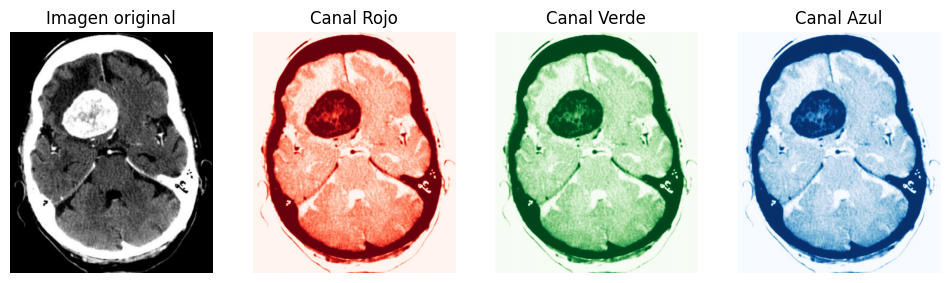

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize # para algoritmo de optimización

# Cargar imagen a color
img = cv2.imread('/content/tumor.jpg')  # Cambia 'imagen.jpg' por la ruta de tu imagen
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir de BGR (OpenCV) a RGB

# Separar canales
R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]

# Mostrar los canales por separado
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(R, cmap='Reds')
plt.title('Canal Rojo')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(G, cmap='Greens')
plt.title('Canal Verde')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(B, cmap='Blues')
plt.title('Canal Azul')
plt.axis('off')
plt.show()

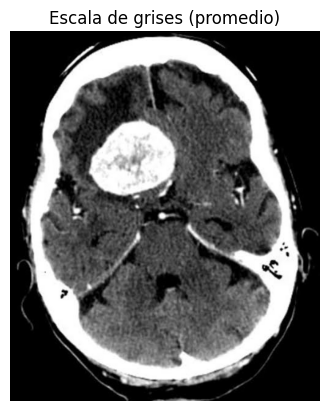

In [15]:
# Convertir a escala de grises promediando canales
gray_avg = ((R.astype(np.float32) + G + B) / 3).astype(np.uint8)

# Mostrar imagen en escala de grises
plt.imshow(gray_avg, cmap='gray')
plt.title('Escala de grises (promedio)')
plt.axis('off')
plt.show()

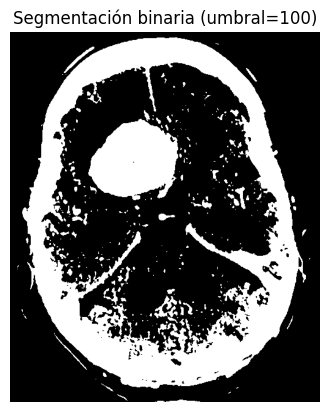

In [16]:
# Umbral para segmentación
umbral = 100
_, segmentada = cv2.threshold(gray_avg, umbral, 255, cv2.THRESH_BINARY)

# Mostrar imagen segmentada
plt.imshow(segmentada, cmap='gray')
plt.title(f'Segmentación binaria (umbral={umbral})')
plt.axis('off')
plt.show()

In [17]:
# Normalizar canales entre 0 y 1
R_norm = R.astype(np.float32) / 255
G_norm = G.astype(np.float32) / 255
B_norm = B.astype(np.float32) / 255

# Función objetivo: varianza negativa (porque minimize() minimiza)
def grayscale_variance(weights):
    w_r, w_g, w_b = weights
    gray = w_r * R_norm + w_g * G_norm + w_b * B_norm
    gray_normalized = (gray - gray.min()) / (gray.max() - gray.min())
    return -np.var(gray_normalized)  # Negativo para maximizar

# Restricción: suma de pesos debe ser 1
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

# Límites de cada peso: entre 0 y 1
bounds = [(0, 1), (0, 1), (0, 1)]

# Valor inicial
initial_weights = [0.33, 0.33, 0.34]

# Optimización
result = minimize(grayscale_variance, initial_weights, method='SLSQP',
                  bounds=bounds, constraints=constraints)

optimal_weights = result.x
print("Pesos óptimos:", optimal_weights)

Pesos óptimos: [0.33 0.33 0.34]


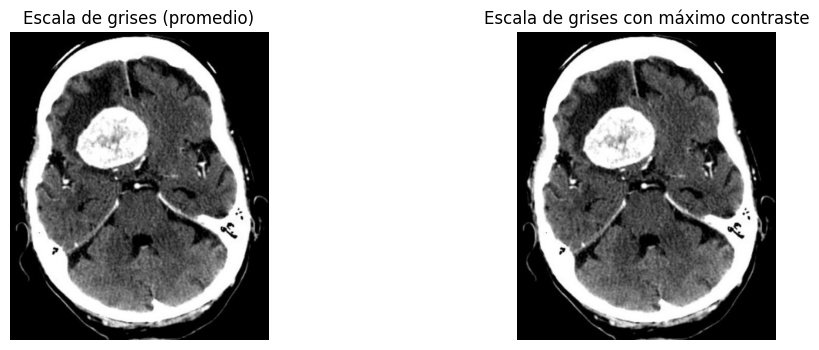

In [18]:
# Crear imagen en escala de grises con pesos óptimos
gray_optimal = optimal_weights[0] * R_norm + optimal_weights[1] * G_norm + optimal_weights[2] * B_norm
gray_optimal = (gray_optimal * 255).astype(np.uint8)

# Mostrar resultado
# Imagen obtenida de manera directa o sencilla
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray_avg, cmap='gray')
plt.title('Escala de grises (promedio)')
plt.axis('off')

# Imagen obtenida de manera óptima
plt.subplot(1, 2, 2)
plt.imshow(gray_optimal, cmap='gray')
plt.title('Escala de grises con máximo contraste')
plt.axis('off')
plt.show()

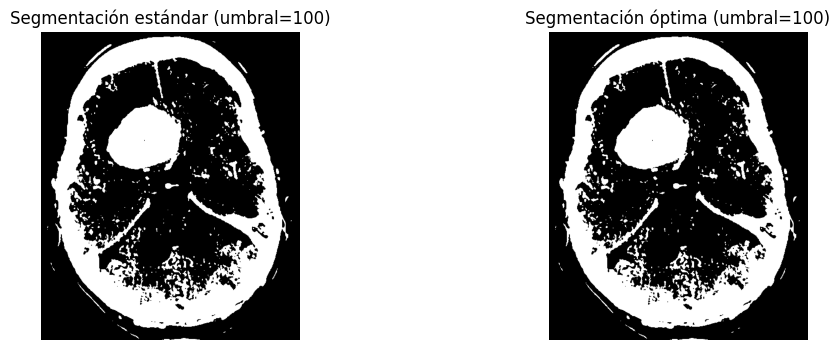

In [19]:
# Segmentar ambas imágenes con un mismo umbral
umbral = 100
_, seg_standard = cv2.threshold(gray_avg, umbral, 255, cv2.THRESH_BINARY)
_, seg_optimal = cv2.threshold(gray_optimal, umbral, 255, cv2.THRESH_BINARY)

# Mostrar resultado
# Imagen obtenida de manera directa o sencilla
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(seg_standard, cmap='gray')
plt.title(f'Segmentación estándar (umbral={umbral})')
plt.axis('off')

# Imagen obtenida de manera óptima
plt.subplot(1, 2, 2)
plt.imshow(seg_optimal, cmap='gray')
plt.title(f'Segmentación óptima (umbral={umbral})')
plt.axis('off')
plt.show()

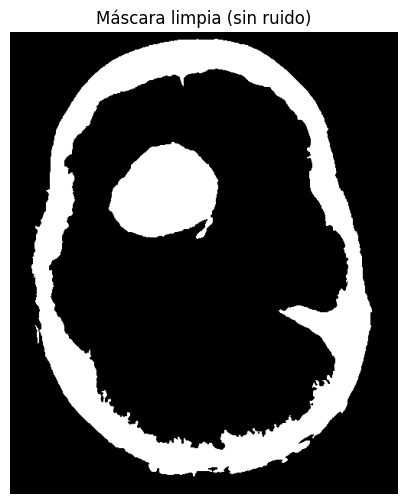

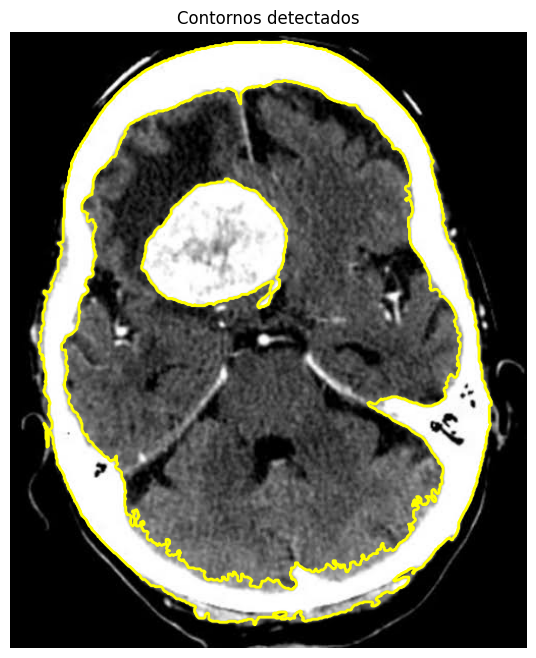

Área del tumor (pixeles): 13027.0


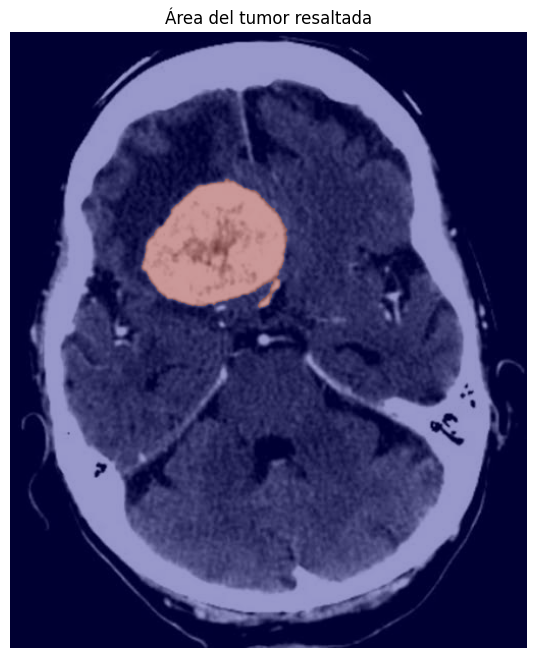

In [22]:

#ELIMINAR RUIDO DE LA MÁSCARA BINARIA

def clean_mask(binary_mask):
    # Asegurar que es booleano
    mask_bool = binary_mask.astype(bool)

    # Eliminar objetos pequeños < 500 pixeles
    clean = morphology.remove_small_objects(mask_bool, min_size=500)

    # Rellenar huecos pequeños < 500 pixeles
    clean = morphology.remove_small_holes(clean, area_threshold=500)
    return clean

clean = clean_mask(binary_opt)

plt.figure(figsize=(6,6))
plt.imshow(clean, cmap='gray')
plt.title('Máscara limpia (sin ruido)')
plt.axis('off')
plt.show()

# EXTRACCIÓN DE CONTORNOS

def plot_contours_on_image(image, binary_mask):
    contours = measure.find_contours(binary_mask, level=0.8)

    plt.figure(figsize=(8,8))
    plt.imshow(image)
    for contour in contours:
        plt.plot(contour[:, 1], contour[:, 0], linewidth=2, color='yellow')
    plt.title('Contornos detectados')
    plt.axis('off')
    plt.show()

plot_contours_on_image(image, clean)

# CÁLCULO DEL ÁREA DEL TUMOR

def calculate_tumor_area(binary_mask):
    labels = measure.label(binary_mask)
    regions = measure.regionprops(labels)

    if len(regions) == 0:
        print("No se encontraron regiones en la máscara.")
        return 0, None

    # Ordenar por área descendente
    regions_sorted = sorted(regions, key=lambda r: r.area, reverse=True)

    # Asumimos que la región más grande es cráneo y la siguiente el tumor
    if len(regions_sorted) >= 2:
        tumor_region = regions_sorted[1]
    else:
        tumor_region = regions_sorted[0]

    area = tumor_region.area
    return area, tumor_region.label

area_tumor, label_tumor = calculate_tumor_area(clean)

print(f"Área del tumor (pixeles): {area_tumor}")

# Mostrar máscara tumor resaltada sobre la imagen
if label_tumor is not None:
    tumor_mask = (measure.label(clean) == label_tumor)

    plt.figure(figsize=(8,8))
    plt.imshow(image)
    plt.imshow(tumor_mask, cmap='jet', alpha=0.4)
    plt.title("Área del tumor resaltada")
    plt.axis('off')
    plt.show()
